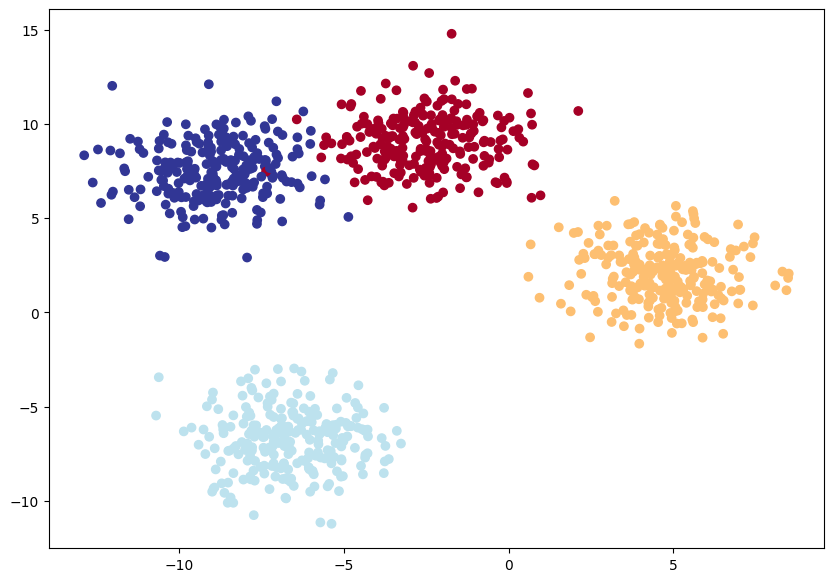

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch.nn as nn

#set the hyperparams for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42
#create a multiclass data
X_blob,y_blob=make_blobs(n_samples=1000,
                         n_features=NUM_FEATURES,
                         centers=NUM_CLASSES,
                         cluster_std=1.5,
                         random_state=RANDOM_SEED)

#turn data into tensors
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)

#split into train test
X_train,X_test,y_train,y_test=train_test_split(X_blob,
                                               y_blob,
                                               test_size=0.2,
                                               random_state=RANDOM_SEED)

#plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob, cmap=plt.cm.RdYlBu)

In [ ]:
#building a multi class classification odel in pytorch
#create a device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [ ]:
#build the model
class BlobModelV1(torch.nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    super().__init__()
    self.linear_layer_stack=torch.nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)
#create an intsance
model=BlobModelV1(input_features=2,output_features=4,hidden_units=8).to(device)

In [ ]:
#create a loss function and optimzer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = (y_true == y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
#create a training loop and a testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100

X_blob_train,y_blob_train=X_train.to(device),y_train.to(device)
X_blob_test,y_blob_test=X_test.to(device),y_test.to(device)

#loop
for epoch in range(epochs):
  model.train()
  y_logits=model(X_blob_train)
  y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss=loss_fn(y_logits,y_blob_train)
  acc=accuracy_fn(y_true=y_blob_train,y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #testing
  model.eval()
  with torch.inference_mode():
    test_logits=model(X_blob_test)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,y_blob_test)
    test_acc=accuracy_fn(y_true=y_blob_test,y_pred=test_pred)

  if epoch%10==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.15883 | Acc: 40.38% | Test Loss: 1.07554 | Test Acc: 48.00%
Epoch: 10 | Loss: 0.64476 | Acc: 96.75% | Test Loss: 0.66069 | Test Acc: 97.50%
Epoch: 20 | Loss: 0.42535 | Acc: 98.50% | Test Loss: 0.43074 | Test Acc: 100.00%
Epoch: 30 | Loss: 0.25294 | Acc: 99.12% | Test Loss: 0.24508 | Test Acc: 99.50%
Epoch: 40 | Loss: 0.11232 | Acc: 99.25% | Test Loss: 0.10229 | Test Acc: 99.50%
Epoch: 50 | Loss: 0.06627 | Acc: 99.25% | Test Loss: 0.05848 | Test Acc: 99.50%
Epoch: 60 | Loss: 0.05068 | Acc: 99.25% | Test Loss: 0.04293 | Test Acc: 99.50%
Epoch: 70 | Loss: 0.04300 | Acc: 99.25% | Test Loss: 0.03491 | Test Acc: 99.50%
Epoch: 80 | Loss: 0.03836 | Acc: 99.25% | Test Loss: 0.02988 | Test Acc: 99.50%
Epoch: 90 | Loss: 0.03525 | Acc: 99.25% | Test Loss: 0.02663 | Test Acc: 99.50%


In [ ]:
# visualize the prediction
model.eval()
with torch.inference_mode():
  y_logits=model(X_blob_test)

y_pred_probs=torch.softmax(y_logits,dim=1)

y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

In [ ]:
import numpy as np

def plot_decision_boundary(model, X, y):
    model.eval()

    X = X.cpu()
    y = y.cpu()

    x_min, x_max = X[:, 0].min()-0.1, X[:, 0].max()+0.1
    y_min, y_max = X[:, 1].min()-0.1, X[:, 1].max()+0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    X_to_pred = torch.from_numpy(
        np.column_stack((xx.ravel(), yy.ravel()))
    ).float()

    with torch.inference_mode():
        logits = model(X_to_pred)
        preds = torch.softmax(logits, dim=1).argmax(dim=1)

    preds = preds.reshape(xx.shape).numpy()

    plt.contourf(xx, yy, preds, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)

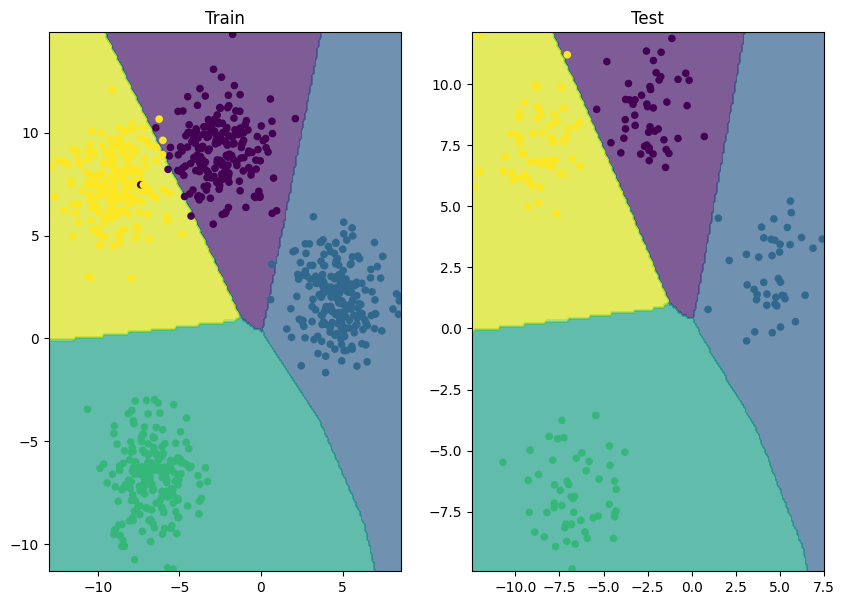

In [ ]:
# move model to CPU (tempo)
model_cpu = model.cpu()

plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_cpu, X_blob_train, y_blob_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_cpu, X_blob_test, y_blob_test)

plt.show()